In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns # Importação adicionada para visualização da matriz de confusão
from nltk.corpus import stopwords
import nltk

In [15]:
# 1. Carregamento e Adaptação dos Dados 

In [16]:
# Seu caminho para o arquivo CSV real
file_path = 'C:/Users/user/Documents/EBAC/dados/Historico_de_materias.csv'

# Nomes das colunas no seu dataset, conforme sua especificação
TEXT_COLUMN = 'conteudo_noticia'    # Coluna que contém o texto da notícia
CATEGORY_COLUMN = 'assunto'         # Coluna que contém a categoria/tópico da notícia

try:
    df = pd.read_csv(file_path, sep=',', engine='python', quotechar='"', on_bad_lines='skip')
    print(f"DataFrame '{file_path}' carregado com sucesso!")
    print(f"Número de registros originais no dataset: {len(df)}")
    print("Colunas disponíveis:", df.columns.tolist())

 # Verificar se as colunas esperadas existem
    if TEXT_COLUMN not in df.columns:
        raise ValueError(f"Coluna '{TEXT_COLUMN}' não encontrada no DataFrame. Por favor, verifique o nome da coluna de conteúdo da notícia.")
    if CATEGORY_COLUMN not in df.columns:
        raise ValueError(f"Coluna '{CATEGORY_COLUMN}' não encontrada no DataFrame. Por favor, verifique o nome da coluna de assunto/categoria.")

    # Remover linhas onde a coluna de texto ou categoria está vazia/nula
    # Isso é crucial para evitar erros no processamento e no treinamento
    df.dropna(subset=[TEXT_COLUMN, CATEGORY_COLUMN], inplace=True)
    print(f"Número de registros após remover nulos: {len(df)}")

    # Converter a coluna de texto para string para garantir que o vetorizador funcione corretamente
    df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)

    # Filtrar categorias/assuntos com poucas amostras para evitar erros no StratifiedKFold
    # É importante ter pelo menos 2 amostras por classe para o train_test_split com stratify
    min_samples_per_class = 2
    category_counts = df[CATEGORY_COLUMN].value_counts()
    categories_to_keep = category_counts[category_counts >= min_samples_per_class].index
    df = df[df[CATEGORY_COLUMN].isin(categories_to_keep)]
    print(f"\nContagem de categorias/assuntos após filtragem (min {min_samples_per_class} amostras):")
    print(df[CATEGORY_COLUMN].value_counts())

    # Opcional: Pegar uma amostra para agilizar o processamento em PCs mais fracos
    # Comente ou ajuste o 'n' conforme a capacidade do seu PC e o tamanho total do dataset
    if len(df) > 15000: # Se o DataFrame for muito grande, pegue uma amostra
        df = df.sample(n=15000, random_state=42).reset_index(drop=True)
    elif len(df) > 5000 and len(df) <= 15000: # Para datasets de tamanho médio
        df = df.sample(n=5000, random_state=42).reset_index(drop=True)
    
    print(f"\nDataFrame final (amostra se grande, nulos e classes raras removidos):")
    print(df.head())

except FileNotFoundError:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado.")
    print("Verifique o caminho do arquivo e se ele está nomeado como 'Historico_de_materias.csv'.")
    print("O script será encerrado.")
    exit() # Encerra o script se o arquivo principal não for encontrado
except ValueError as e:
    print(f"Erro de configuração do DataFrame: {e}")
    print("Verifique os nomes das colunas TEXT_COLUMN e CATEGORY_COLUMN no script.")
    print("O script será encerrado.")
    exit()


DataFrame 'C:/Users/user/Documents/EBAC/dados/Historico_de_materias.csv' carregado com sucesso!
Número de registros originais no dataset: 10109
Colunas disponíveis: ['data', 'url_noticia', 'url_noticia_curto', 'titulo', 'conteudo_noticia', 'assunto']
Número de registros após remover nulos: 10103

Contagem de categorias/assuntos após filtragem (min 2 amostras):
assunto
esportes      6030
economia      1558
politica      1363
tecnologia     612
famosos        540
Name: count, dtype: int64

DataFrame final (amostra se grande, nulos e classes raras removidos):
         data                                        url_noticia  \
0  2014-09-12  https://web.archive.org/web/20140912233210/htt...   
1  2018-03-22  https://web.archive.org/web/20180322003519/htt...   
2  2018-03-08  https://web.archive.org/web/20180308044323/htt...   
3  2014-08-08  https://web.archive.org/web/20140808030952/htt...   
4  2019-01-29  https://web.archive.org/web/20190129025352/htt...   

                            

In [17]:
# 2. Pré-processamento dos Dados

In [18]:
# Codificação da variável target (assuntos/categorias)
label_encoder = LabelEncoder()
df[CATEGORY_COLUMN + '_encoded'] = label_encoder.fit_transform(df[CATEGORY_COLUMN])

print(f"\nMapeamento de categorias/assuntos para números: {list(label_encoder.classes_)}")


Mapeamento de categorias/assuntos para números: ['economia', 'esportes', 'famosos', 'politica', 'tecnologia']


In [19]:
# Divisão dos dados em treino e teste
X = df[TEXT_COLUMN]
y = df[CATEGORY_COLUMN + '_encoded']

In [20]:
# Usar stratify=y é CRUCIAL para garantir que a proporção das categorias seja mantida
# nos conjuntos de treino e teste, especialmente se houver desbalanceamento de classes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nNúmero de amostras de treino: {len(X_train)}")
print(f"Número de amostras de teste: {len(X_test)}")


Número de amostras de treino: 4000
Número de amostras de teste: 1000


In [35]:
# Baixar as stopwords se ainda não tiver
nltk.download('stopwords')

# Lista de stopwords em português
stopwords_pt = stopwords.words('portuguese')

# Vetorização do texto usando TF-IDF com stopwords em português
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=stopwords_pt,
    ngram_range=(1, 2)
)

# Aplica a vetorização nos dados
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Exibe o formato das matrizes geradas
print(f"Formato dos dados de treino TF-IDF: {X_train_tfidf.shape}")
print(f"Formato dos dados de teste TF-IDF: {X_test_tfidf.shape}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Formato dos dados de treino TF-IDF: (4000, 5000)
Formato dos dados de teste TF-IDF: (1000, 5000)


In [36]:
# Análise de palavras TF-IDF (opcional, pode ser pesado para grandes datasets)
# Esta parte pode consumir muita memória se o dataset for muito grande.
# Se o script travar aqui, comente este bloco.
try:
    print("\nIniciando análise de palavras/bigramas por TF-IDF (pode demorar ou consumir muita memória)...")
    words = tfidf_vectorizer.get_feature_names_out()
    # Usamos X_train_tfidf.toarray() para calcular a média, pois ele é um Sparse Matrix
    mean_tfidf = X_train_tfidf.toarray().mean(axis=0)
    tfidf_df = pd.DataFrame(data={'Word': words, 'Mean_TFIDF': mean_tfidf})
    tfidf_df = tfidf_df.sort_values(by='Mean_TFIDF', ascending=False)
    print("Top 20 palavras/bigramas por média TF-IDF no conjunto de treino:")
    print(tfidf_df.head(20))
except MemoryError:
    print("\nErro de memória ao converter TF-IDF para array para análise de palavras. Pulando esta seção.")
except Exception as e:
    print(f"\nErro inesperado durante a análise de palavras: {e}. Pulando esta seção.")



Iniciando análise de palavras/bigramas por TF-IDF (pode demorar ou consumir muita memória)...
Top 20 palavras/bigramas por média TF-IDF no conjunto de treino:
            Word  Mean_TFIDF
2059       feira    0.019521
407          ano    0.019205
297        ainda    0.018467
4372       sobre    0.018188
3702  presidente    0.018135
2605        jogo    0.017647
412         anos    0.017622
1211      contra    0.017471
745       brasil    0.017115
1003       clube    0.017071
4268     segundo    0.016484
1590       disse    0.016028
1517         dia    0.015873
3169       nesta    0.015841
488         após    0.015522
4561        time    0.015172
4765         vai    0.014613
4529         ter    0.014411
3447       paulo    0.014315
2600     jogador    0.013827


In [37]:
# 3. Treinamento do Modelo de Classificação

In [38]:
# Treinamento do modelo de Regressão Logística
# max_iter: aumentado para garantir a convergência, especialmente com dados de texto.
# C: parâmetro de regularização (menor C -> maior regularização; 1.0 é um bom ponto de partida).
# n_jobs=-1: utiliza todos os núcleos da CPU para paralelizar o treinamento, acelerando-o.
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
model.fit(X_train_tfidf, y_train)

print("\nModelo de Regressão Logística treinado com sucesso!")


Modelo de Regressão Logística treinado com sucesso!


In [39]:
# 4. Avaliação do Modelo

In [40]:
# Previsões no conjunto de teste
y_pred = model.predict(X_test_tfidf)

# Acurácia: proporção de previsões corretas.
accuracy = accuracy_score(y_test, y_pred)
print(f'\nAcurácia do modelo: {accuracy:.4f}')

# Matriz de Confusão: resume o desempenho do modelo de classificação.
conf_matrix = confusion_matrix(y_test, y_pred)
print('\nMatriz de Confusão:')
print(conf_matrix)


Acurácia do modelo: 0.9580

Matriz de Confusão:
[[145   1   0   8   1]
 [  0 599   1   1   1]
 [  1  11  42   0   0]
 [  4   5   0 123   0]
 [  6   2   0   0  49]]


In [41]:
# Podemos ver o alto indice de acuraria e tambem notar pelo alto nivel de acertabilidade na diagonal principal pelas classificacoes corretas!

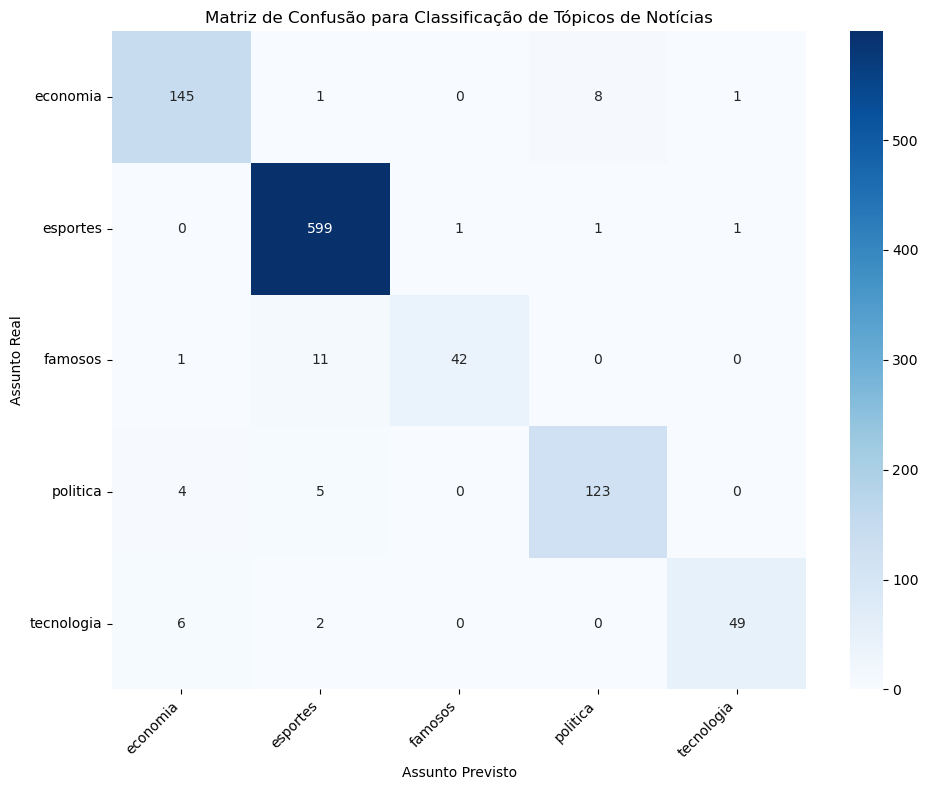

In [43]:
# Visualização da Matriz de Confusão para melhor interpretabilidade
plt.figure(figsize=(10, 8)) # Aumentei o tamanho para melhor visualização das labels
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, # Nomes reais das categorias no eixo X (Previsão)
            yticklabels=label_encoder.classes_) # Nomes reais das categorias no eixo Y (Real)
plt.title('Matriz de Confusão para Classificação de Tópicos de Notícias')
plt.xlabel('Assunto Previsto')
plt.ylabel('Assunto Real')
plt.xticks(rotation=45, ha='right') # Rotaciona os labels do eixo X para evitar sobreposição
plt.yticks(rotation=0)              # Mantém os labels do eixo Y horizontais
plt.tight_layout()                  # Ajusta o layout para não cortar labels
plt.show()

In [44]:
# Relatório de Classificação: fornece métricas detalhadas por classe (precisão, recall, F1-score).
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print('\nRelatório de Classificação:')
print(class_report)


Relatório de Classificação:
              precision    recall  f1-score   support

    economia       0.93      0.94      0.93       155
    esportes       0.97      1.00      0.98       602
     famosos       0.98      0.78      0.87        54
    politica       0.93      0.93      0.93       132
  tecnologia       0.96      0.86      0.91        57

    accuracy                           0.96      1000
   macro avg       0.95      0.90      0.92      1000
weighted avg       0.96      0.96      0.96      1000



In [45]:
# 5. Testando o Modelo com Novas Notícias (Exemplos do Prompt)

In [46]:
print("\n--- Testando o Modelo com Novas Notícias de Exemplo do Prompt ---")
# Estes são os exemplos que o modelo deve classificar, conforme o prompt.
new_news_examples = [
    "Bolsa de valores atinge novo recorde impulsionada por setor de energia.", # Economia
    "Nova vacina contra a gripe é aprovada para uso emergencial.", # Saúde
    "Seleção nacional vence amistoso preparatório para o campeonato mundial.", # Esportes
    "Debate sobre reforma tributária domina sessão no Congresso.", # Política
    "Empresa lança smartphone dobrável com inteligência artificial avançada.", # Tecnologia
    "Crescimento do PIB surpreende analistas no último trimestre.", # Economia
    "Protocolo para tratamento de doença rara recebe atualização.", # Saúde
    "Presidente sanciona lei de incentivo à pesquisa científica.", # Política
    "Gigante da tecnologia anuncia demissão em massa após balanço negativo.", # Economia
    "Pesquisa revela avanços na terapia gênica para doenças crônicas.", # Saúde
    "Equipe brasileira conquista medalha de ouro nas Olimpíadas de Inverno.", # Esportes
    "Cybersegurança: Novo ataque de ransomware afeta grandes corporações.", # Tecnologia
    "Ministério da Justiça investiga denúncias de corrupção." # Política
]


--- Testando o Modelo com Novas Notícias de Exemplo do Prompt ---


In [47]:
# Vetorizar as novas notícias usando o MESMO vetorizador treinado (tfidf_vectorizer).
# É crucial usar o mesmo vetorizador para transformar os novos dados.
new_news_tfidf = tfidf_vectorizer.transform(new_news_examples)

# Fazer previsões com o modelo treinado
new_news_predictions_encoded = model.predict(new_news_tfidf)

# Decodificar as previsões numéricas de volta para os nomes das categorias originais
new_news_predictions = label_encoder.inverse_transform(new_news_predictions_encoded)

print("\nPrevisões para as notícias de exemplo:")
for i, news in enumerate(new_news_examples):
    print(f"Notícia: \"{news}\"\nPrevisão: {new_news_predictions[i]}\n")


Previsões para as notícias de exemplo:
Notícia: "Bolsa de valores atinge novo recorde impulsionada por setor de energia."
Previsão: economia

Notícia: "Nova vacina contra a gripe é aprovada para uso emergencial."
Previsão: esportes

Notícia: "Seleção nacional vence amistoso preparatório para o campeonato mundial."
Previsão: esportes

Notícia: "Debate sobre reforma tributária domina sessão no Congresso."
Previsão: esportes

Notícia: "Empresa lança smartphone dobrável com inteligência artificial avançada."
Previsão: tecnologia

Notícia: "Crescimento do PIB surpreende analistas no último trimestre."
Previsão: economia

Notícia: "Protocolo para tratamento de doença rara recebe atualização."
Previsão: esportes

Notícia: "Presidente sanciona lei de incentivo à pesquisa científica."
Previsão: politica

Notícia: "Gigante da tecnologia anuncia demissão em massa após balanço negativo."
Previsão: esportes

Notícia: "Pesquisa revela avanços na terapia gênica para doenças crônicas."
Previsão: espo

In [ ]:
# Apontamento de Boas Práticas na Elaboração do Prompt

# Na criação do prompt para o modelo de classificação de tópicos de notícias, empreguei várias boas práticas para maximizar sua eficácia e garantir que 
# o modelo compreenda a tarefa com clareza e precisão. Abaixo, listo e justifico três delas:

# Clareza e Especificidade da Tarefa:

# Justificativa: O prompt inicia com uma declaração direta sobre o papel do modelo ("Você é um sistema de classificação de notícias altamente preciso") 
# e define explicitamente a tarefa ("Sua tarefa é analisar o conteúdo de uma notícia e categorizá-la em uma das seguintes seções: Política, Economia, 
# Saúde, Esportes, Tecnologia"). Essa abordagem elimina qualquer ambiguidade, direcionando o modelo para o objetivo exato e fornecendo um conjunto 
# fechado de categorias. Isso impede que o modelo "alucine" ou retorne resultados fora do escopo desejado, garantindo uma saída previsível e utilizável.
# Fornecimento de Múltiplos e Diversos Exemplos (Few-shot Learning):

# Justificativa: Inseri 13 exemplos variados de notícias com suas respectivas categorias. Essa técnica, conhecida como "few-shot learning", 
# é fundamental para modelos de linguagem grandes. Os exemplos servem como demonstrações concretas, permitindo que o modelo aprenda padrões de 
# mapeamento de texto para categoria não apenas a partir das instruções explícitas, mas também inferindo a partir da relação entre as entradas e 
# saídas demonstradas. A diversidade dos exemplos, cobrindo todas as categorias e apresentando cenários que poderiam ser ambíguos (como notícias 
# de tecnologia que abordam economia), melhora significativamente a capacidade de generalização do modelo e sua consistência nas classificações.

#Definição Clara do Formato de Saída e Contexto Adicional para Nuances:

# Justificativa: O prompt especifica explicitamente o "Formato de Saída: A saída deve ser apenas a categoria, sem explicações adicionais". 
# Essa padronização é vital para a automação e integração do modelo em sistemas maiores, garantindo que a saída seja concisa e fácil de ser processada. 
# Além disso, a seção "Contexto Adicional" aborda situações complexas e nuances ("Notícias sobre 'legislação para startups' devem ser classificadas 
# como 'Tecnologia' se o foco for a inovação, ou 'Política' se o foco for o processo legislativo..."). Esse tipo de orientação refinada é crucial para 
# que o modelo tome decisões mais informadas em casos limítrofes, reduzindo a ambiguidade e aprimorando a qualidade e a consistência das classificações,
# especialmente em um domínio tão rico e multifacetado quanto o das notícias.

In [ ]:
# Reflexão Ética: Garantindo o Uso Responsável de Modelos de Classificação de Notícias

# A implantação de um modelo de classificação de notícias, como o que acabamos de construir, vai além da precisão técnica; 
# exige um compromisso firme com a ética e a conformidade legal, especialmente com a Lei Geral de Proteção de Dados (LGPD).

# A transparência na classificação de notícias é crucial. Usuários e produtores de conteúdo têm o direito de entender como as notícias são categorizadas.
# Isso significa ser claro que a classificação é realizada por um algoritmo de IA e, sempre que possível, explicar os critérios ou a "lógica" que levou 
# a uma notícia a ser alocada em "Política" ou "Economia". A opacidade pode minar a confiança do público, alimentando desinformação e suspeitas sobre a 
# imparcialidade da categorização, algo particularmente sensível em setores como jornalismo. Um sistema transparente não só promove a confiança, mas 
# também facilita a auditoria e correção de possíveis falhas.

# Para evitar preconceitos na categorização de assuntos, é imperativo um olhar crítico sobre o conjunto de dados de treinamento. 
# Se os dados históricos refletem vieses sociais, demográficos ou ideológicos (por exemplo, notícias sobre certas comunidades serem 
# desproporcionalmente rotuladas de uma forma específica), o modelo aprenderá e amplificará esses vieses. Isso pode resultar em classificações 
# discriminatórias, marginalização de determinados temas ou perpetuação de estereótipos. A mitigação exige a curadoria cuidadosa do dataset, 
# buscando diversidade e representatividade, e a implementação de auditorias contínuas do modelo após a implantação, utilizando métricas de justiça 
# para identificar e corrigir tendências enviesadas, garantindo que o modelo seja equitativo em suas classificações.

# Por fim, a proteção de dados sensíveis ou informações pessoais contidas nas notícias é uma exigência da LGPD. Mesmo que o modelo em si não colete 
# dados de usuários, ele processa o conteúdo das notícias, que pode incidentalmente conter informações sensíveis (saúde de indivíduos, detalhes de 
# incidentes criminais com vítimas identificáveis, etc.). É fundamental garantir que esses dados não sejam armazenados indevidamente, utilizados para 
# fins não autorizados ou vazados. Práticas como a anonimização ou pseudonimização de dados sensíveis antes do processamento pelo modelo são essenciais,
# quando aplicável. Além disso, as políticas de retenção de dados e os controles de acesso ao conteúdo processado devem aderir estritamente às 
# diretrizes da LGPD, assegurando que apenas as informações estritamente necessárias para a classificação sejam utilizadas e por tempo limitado, 
# minimizando riscos e demonstrando conformidade legal e ética.